# Step 1: Import libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Support function for visualization
import matplotlib.pyplot as plt

def show_image(img: np.ndarray, title: str = "") -> None:
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

# Step 2: Download and load the image

In [3]:
# https://drive.google.com/file/d/12jWZPdhw4LDTMY9FNA5_HdFLc5SN65Rf/view?usp=sharing
# https://drive.google.com/file/d/1gMinoV9tDStKXuUGpbI2h5S7wViw0AaK/view?usp=sharing
# https://drive.google.com/file/d/1pwTWcdkY3VOudV0rxKIPjue1DCC4j8W2/view?usp=sharing
#!gdown 12jWZPdhw4LDTMY9FNA5_HdFLc5SN65Rf
#!gdown 1gMinoV9tDStKXuUGpbI2h5S7wViw0AaK
#!gdown 1pwTWcdkY3VOudV0rxKIPjue1DCC4j8W2

In [4]:
IMG_SIZE = (678, 381)

bg1_image = cv2.resize(cv2.imread("../Data/GreenBackground.png"), IMG_SIZE)
ob_image = cv2.resize(cv2.imread("../Data/Object.png"), IMG_SIZE)
bg2_image = cv2.resize(cv2.imread("../Data/NewBackground.jpg"), IMG_SIZE)
print(bg1_image.shape, ob_image.shape, bg2_image.shape)

(381, 678, 3) (381, 678, 3) (381, 678, 3)


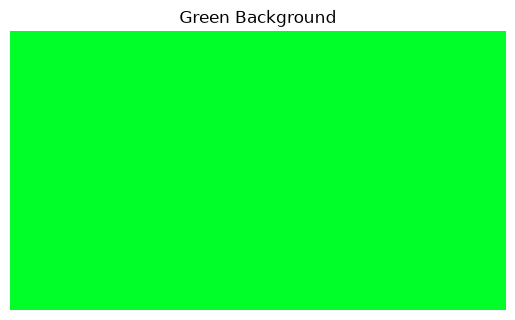

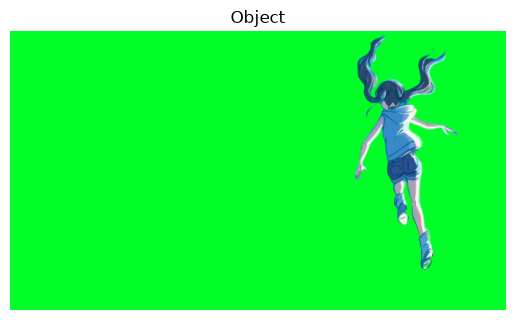

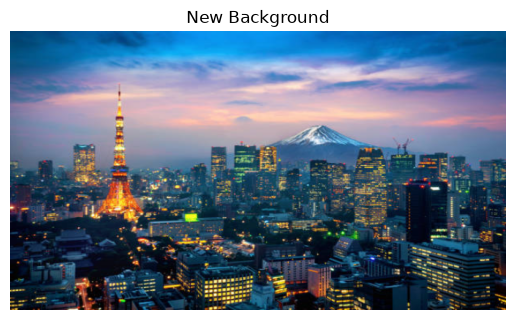

In [5]:
show_image(bg1_image, "Green Background")
show_image(ob_image, "Object")
show_image(bg2_image, "New Background")

## Step 3: Implement support functions

In [6]:
def compute_difference(bg_img: np.ndarray, input_img: np.ndarray) -> np.ndarray:
    # YOUR CODE HERE
    # Hint: cast to a signed dtype first so the subtraction doesn't wrap around,
    # then take the absolute value and average over the channel axis.
    bg_img = bg_img.astype(float)
    input_img = input_img.astype(float)

    diff = np.abs(input_img - bg_img)
    diff = diff.mean(axis=2).astype("uint8")
    return diff

difference_single_channel = compute_difference(bg1_image, ob_image)
print(difference_single_channel.shape)

(381, 678)


In [7]:
def compute_binary_mask(difference_single_channel: np.ndarray) -> np.ndarray:
    # YOUR CODE HERE
    # Hint: threshold the difference (e.g. >= 15) into 0/255, then stack it
    # into 3 channels so it can be compared against a color image.
    mask = np.where(difference_single_channel >= 15, 255, 0)
    return np.stack((mask,)*3, axis=2)


binary_mask = compute_binary_mask(difference_single_channel)

## Step 4: Background Replacement

In [8]:
def replace_background(bg1_image: np.ndarray, bg2_image: np.ndarray, ob_image: np.ndarray) -> np.ndarray:
    difference_single_channel = compute_difference(bg1_image, ob_image)
    binary_mask = compute_binary_mask(difference_single_channel)
    # YOUR CODE HERE
    # Hint: where the mask is 255, keep the object. Otherwise, use the new background.
    return np.where(binary_mask == 255, ob_image, bg2_image)


output = replace_background(bg1_image, bg2_image, ob_image)

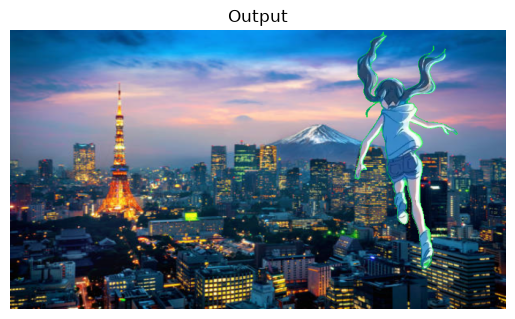

In [9]:
show_image(output, "Output")